##**Review Intelligence Pipeline - Improving a Basic LSTM Model**
This notebook builds an LSTM-based sentiment classifier and iteratively improves it across several experiments. Unlike BoW models, which treat a review as an unordered collection of words, an LSTM processes the review as a sequence — maintaining a hidden memory state that's updated at each word, allowing it to capture context and word order (e.g. distinguishing "good" from "not good").

**Goal:** Build a working LSTM classifier, then iteratively improve it (dropout, vocabulary cleaning, pretrained embeddings) while monitoring for overfitting using a validation set and early stopping.

**Result:** 56% accuracy (matching the BoW baseline) — the largest single improvement came from pretrained GloVe embeddings, which closed the gap left by random embedding initialization on a relatively small training set.

#**Importing Libraries**

Directly using the **HuggingFace** datasets library to load **Yelp Review Full** dataset instead of manually downloading and parsing it.

Link: [Yelp/yelp_review_full](https://huggingface.co/datasets/Yelp/yelp_review_full)

In [2]:
import datasets
from datasets import load_dataset

In [3]:
dataset = load_dataset("Yelp/yelp_review_full")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

Converting to Pandas dataframe for easier exploration

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(dataset['train'])
df.head()

,label,text
0,4,dr. goldberg offers everything i look for in a...
1,1,"Unfortunately, the frustration of being Dr. Go..."
2,3,Been going to Dr. Goldberg for over 10 years. ...
3,3,Got a letter in the mail last week that said D...
4,0,I don't know what Dr. Goldberg was like before...


In [19]:
dfSubset = df[df['label']==0][:2000]
for i in range(1,5):
  dfSubset = pd.concat([dfSubset,df[df['label']==i][:2000]],axis=0,ignore_index=True)
dfSubset.describe()

,label
count,10000.000000
mean,2.000000
std,1.414284
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


Splitting into **train-test split** datasets.

In [20]:
from sklearn.model_selection import train_test_split
X, y = dfSubset['text'], dfSubset['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42,stratify=y)

**Vocab** is necessary to build in an LSTM model. It simply is a dictionary where each word(or called **token**) in the training dataset is assigned an number(or an **index**).

The first element is conventionally `<PAD>` with index 0, as this will be used to make each review of the same length later on.

The second element `<UNK>` is assigned index 1, to replace this in case a new worda appears in the testing set/ or any future unseen text.

In [21]:
vocab = {"<PAD>":0,"<UNK>":1}

In [22]:
for review in X_train:
  for word in review.split():
    if word not in vocab:
      vocab[word] = len(vocab)

In [23]:
len(vocab)

71353

In [24]:
vocab

{'<PAD>': 0,
 '<UNK>': 1,
 'We': 2,
 'have': 3,
 'been': 4,
 'coming': 5,
 'here': 6,
 'since': 7,
 'it': 8,
 'opened,': 9,
 'but': 10,
 'will': 11,
 'not': 12,
 'go': 13,
 'back': 14,
 'after': 15,
 'our': 16,
 'three': 17,
 'last': 18,
 'visits.': 19,
 'It': 20,
 'has': 21,
 'gone': 22,
 'downhill': 23,
 'badly.': 24,
 'Three': 25,
 'visits': 26,
 'ago': 27,
 'we': 28,
 'were': 29,
 'seated': 30,
 'in': 31,
 'the': 32,
 'trolley': 33,
 'and': 34,
 'then': 35,
 'completely': 36,
 'ignored': 37,
 'for': 38,
 '30': 39,
 'minutes.': 40,
 'There': 41,
 'was': 42,
 'a': 43,
 'waitress,': 44,
 'apparently': 45,
 'she': 46,
 'new': 47,
 'only': 48,
 'had': 49,
 'front': 50,
 'half.': 51,
 'I': 52,
 'finally': 53,
 'went': 54,
 'out': 55,
 'demanded': 56,
 'manager': 57,
 'who': 58,
 'assigned': 59,
 'waitress': 60,
 'us': 61,
 "comp'ed": 62,
 'meals.': 63,
 'The': 64,
 'lasagna': 65,
 'very': 66,
 'disappointing': 67,
 'with': 68,
 'hard': 69,
 'noodles': 70,
 'definitely': 71,
 'oven': 72,


**Text to Indices Function** Converts a review into indices based upon the vocabulary already created. Words not seen during vocabulary construction (out-of-vocabulary) fall back to the `<UNK>` index.

In [26]:
def text_to_indices(text: str, vocab = vocab) -> list:
  tokens = text.split()
  indices = []
  for token in tokens:
    if token in vocab:
      indices.append(vocab[token])
    else:
      indices.append(vocab["<UNK>"])
  return indices

var = text_to_indices(X_train.iloc[0])
print(var)



[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 10, 45, 46, 42, 47, 34, 48, 49, 32, 50, 51, 52, 53, 54, 55, 50, 34, 56, 32, 57, 58, 53, 59, 43, 60, 38, 61, 34, 62, 16, 63, 64, 65, 42, 66, 67, 68, 69, 70, 34, 71, 12, 72, 73, 34, 74, 75, 26, 27, 76, 77, 32, 78, 79, 28, 80, 76, 77, 81, 32, 82, 83, 84, 42, 85, 34, 86, 42, 87, 18, 88, 18, 89, 42, 32, 90, 91, 34, 92, 93, 94, 95, 85, 84, 34, 96, 64, 97, 29, 98, 99, 34, 100, 29, 12, 101, 64, 102, 103, 16, 104, 105, 106, 10, 46, 107, 108, 109, 110, 111, 28, 29, 12, 112, 64, 113, 114, 42, 115, 2, 48, 116, 117, 118, 119, 120, 121, 42, 74, 122, 34, 123, 68, 124, 125, 126, 127, 128, 129, 130, 93, 32, 131, 132, 15, 98, 68, 105, 133, 38, 134, 55, 135, 64, 86, 42, 66, 136, 64, 137, 34, 138, 49, 139, 43, 140, 119, 141, 64, 142, 143, 42, 124, 144, 119, 145, 146, 147, 148, 149, 150, 34, 151, 42, 12, 152, 10, 153, 154, 2, 11, 155, 156, 157,

**Padding Function** Pads 0s at the beginning of the list of indices if the length of list is lesser than 200(as seen from EDA, reviews have a mean length of 134). At the beginning because LSTMs read from left to right, and we do not want the model to end on padded sequences. Reviews longer than 200 tokens are truncated.

```
def pad_sequence(indices, max_len=200):
  len_index = len(indices)
  if len_index>max_len:
    indices = indices[:200]
  elif len_index<max_len:
    for i in range(max_len-len_index):
      indices.insert(0,vocab["<PAD>"])
    # print(len(indices))
  return indices
```



In [27]:
def pad_sequence(indices: list, max_len=200)-> list:
  indices = indices[:max_len]
  padding = [0] * (max_len-len(indices))
  return padding + indices


In [28]:
lst1 = text_to_indices(X_train.iloc[0]) #string has 254 words
print(lst1)
print("No. of words in original string: ",len(lst1))
pad_sequence(lst1)
print("No. of words after padding: ",len(pad_sequence(lst1)))

[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 10, 45, 46, 42, 47, 34, 48, 49, 32, 50, 51, 52, 53, 54, 55, 50, 34, 56, 32, 57, 58, 53, 59, 43, 60, 38, 61, 34, 62, 16, 63, 64, 65, 42, 66, 67, 68, 69, 70, 34, 71, 12, 72, 73, 34, 74, 75, 26, 27, 76, 77, 32, 78, 79, 28, 80, 76, 77, 81, 32, 82, 83, 84, 42, 85, 34, 86, 42, 87, 18, 88, 18, 89, 42, 32, 90, 91, 34, 92, 93, 94, 95, 85, 84, 34, 96, 64, 97, 29, 98, 99, 34, 100, 29, 12, 101, 64, 102, 103, 16, 104, 105, 106, 10, 46, 107, 108, 109, 110, 111, 28, 29, 12, 112, 64, 113, 114, 42, 115, 2, 48, 116, 117, 118, 119, 120, 121, 42, 74, 122, 34, 123, 68, 124, 125, 126, 127, 128, 129, 130, 93, 32, 131, 132, 15, 98, 68, 105, 133, 38, 134, 55, 135, 64, 86, 42, 66, 136, 64, 137, 34, 138, 49, 139, 43, 140, 119, 141, 64, 142, 143, 42, 124, 144, 119, 145, 146, 147, 148, 149, 150, 34, 151, 42, 12, 152, 10, 153, 154, 2, 11, 155, 156, 157,

In [29]:
lst2 = text_to_indices(X_train.iloc[1]) #string has 254 words
print(lst2)
print("No. of words in original string: ",len(lst2))
pad_sequence(lst2)
print("No. of words after padding: ",len(pad_sequence(lst2)))
print("Padded Indices: \n",pad_sequence(lst2) )

[169, 170, 171, 55, 108, 172, 173, 105, 119, 32, 174, 6, 175, 176, 52, 177, 66, 178, 76, 179, 180, 55, 181, 182, 34, 3, 183, 184, 105, 185, 186, 32, 187, 20, 93, 188, 173, 189, 29, 190, 191, 32, 192, 31, 193, 10, 189, 175, 194, 195, 196, 130, 197, 111, 105, 181, 198, 199, 200, 201, 190, 202, 203, 204, 205, 206, 207, 208, 209, 93, 190, 202, 124, 210, 197, 31, 211, 212, 213, 206, 214, 215, 216, 175, 217, 115, 64, 218, 175, 219, 32, 216, 3, 220, 119, 221, 34, 32, 222, 175, 223, 224, 225, 52, 226, 189, 227, 228, 229, 230, 231, 52, 232, 233, 234, 166, 32, 235, 236, 34, 237, 238, 239, 240, 12, 43, 241, 119, 173, 242, 243, 244, 245, 175, 246, 247, 231, 189, 11, 228, 248, 173, 93, 249, 250, 251, 252, 253, 246, 227, 254, 255, 256, 64, 257, 93, 223, 258, 34, 189, 11, 259, 216, 248, 250, 260, 261]
No. of words in original string:  167
No. of words after padding:  200
Padded Indices: 
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 169, 170, 171

#**Creating a Custom Dataset Class**
PyTorch's `DataLoader` requires data wrapped in a `Dataset` object that defines how to fetch and format each sample. `YelpDataset` ties together our vocabulary, tokenization, and padding functions — converting raw text and labels into padded tensors on demand, one sample at a time via `__getitem__`(helps iterate through each review).

In [7]:
import torch
from torch.utils.data import Dataset

In [8]:
class YelpDataset(Dataset):
  """
  Accepts raw text of training data and training labels.
  Returns two torch tensors of indices and their labels in of long datatype.
  """
  def __init__(self, text, labels, vocab, max_len=200):
    self.text = text
    self.labels = labels
    self.vocab = vocab
    self.max_len = max_len

  def __len__(self):
    return len(self.text)

  def __getitem__(self, idx):

    return torch.tensor(pad_sequence(text_to_indices(self.text[idx])), dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

In [17]:
train_dataset = YelpDataset(X_train.tolist(), y_train.tolist(), vocab)
test_dataset = YelpDataset(X_test.tolist(), y_test.tolist(), vocab)

print(train_dataset[0])
print(len(train_dataset))

(tensor([  2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,
         16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,
         30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,
         44,  10,  45,  46,  42,  47,  34,  48,  49,  32,  50,  51,  52,  53,
         54,  55,  50,  34,  56,  32,  57,  58,  53,  59,  43,  60,  38,  61,
         34,  62,  16,  63,  64,  65,  42,  66,  67,  68,  69,  70,  34,  71,
         12,  72,  73,  34,  74,  75,  26,  27,  76,  77,  32,  78,  79,  28,
         80,  76,  77,  81,  32,  82,  83,  84,  42,  85,  34,  86,  42,  87,
         18,  88,  18,  89,  42,  32,  90,  91,  34,  92,  93,  94,  95,  85,
         84,  34,  96,  64,  97,  29,  98,  99,  34, 100,  29,  12, 101,  64,
        102, 103,  16, 104, 105, 106,  10,  46, 107, 108, 109, 110, 111,  28,
         29,  12, 112,  64, 113, 114,  42, 115,   2,  48, 116, 117, 118, 119,
        120, 121,  42,  74, 122,  34, 123,  68, 124, 125, 126, 

#**DataLoaders**
Wraps the datasets into `DataLoader` objects, which handle batching (32 samples at a time) and shuffling. Training data is shuffled each epoch to prevent the model from learning any unintended ordering in the data; test data is not shuffled since order doesn't matter for evaluation.

This is what's called during training, validation and testing loops, as they handle batching and shuffling.

In [18]:
from torch.utils.data import DataLoader
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

In [19]:
text, labels = next(iter(train_loader))
print(text.shape) #One batch all with 32 samples and one sample 200 tokens
print(labels.shape) #One batch has 32 labels

torch.Size([32, 200])
torch.Size([32])


In [20]:
train_loader

#**Creating The Model**
A three-layer architecture: Embedding → LSTM → Linear.

- **Embedding** — maps each word index to a dense 128-dimensional vector, learned during training
- **LSTM** — processes the sequence of embeddings one token at a time, building a hidden state that captures context and word order
- **Linear** — maps the LSTM's final hidden state to 5 raw class scores (logits), one per star rating.

The forward pass extracts only the final hidden state (hidden, shape `[1, batch, hidden_dim]`) rather than the LSTM's full output sequence — since classification only needs a single summary vector per review, not per-token outputs.

In [11]:
import torch.nn as nn

In [15]:
class LSTMClassifier(nn.Module):
  def __init__(self, vocab_size: int, embedding_dim: int, hidden_dim: int, output_dim: int):
    super().__init__()
    self.Embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    self.LSTM = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)#expects [batch, seq_len, hidden_dim]
    self.Linear = nn.Linear(hidden_dim, output_dim)


  def forward(self, x):
    embedded = self.Embedding(x) #embedded format: [batch, seq_len, embedding dim] -->batch: no. of samples, seq_len will be 200, embedding dim assign a unique vector to each token(word)
    output, (hidden, cell) = self.LSTM(embedded)
    #LSTM layer returns a tuple (output, (hidden, cell)) of shape [1, batch_size, hidden_dim]
    hidden = hidden.squeeze(0) #after this line hidden has shape [batch, hidden_dim]
    return self.Linear(hidden) #returns shape [32, 5] 32 is the no. of samples and 5 is the logit score per label.


In [30]:
model0 = LSTMClassifier(vocab_size=len(vocab),embedding_dim=128, hidden_dim=256, output_dim=5) #embedding_dim is the no. of elements in the unique vector
print(model0)

LSTMClassifier(
  (Embedding): Embedding(71353, 128, padding_idx=0)
  (LSTM): LSTM(128, 256, batch_first=True)
  (Linear): Linear(in_features=256, out_features=5, bias=True)
)


##**Loss Function and Optimizer**

`CrossEntropyLoss` — standard choice for multi-class classification; internally applies softmax to the model's raw logits before computing loss.

`Adam optimizer` with lr=0.001 — a stable default learning rate for LSTM training. An earlier attempt with lr=0.1 caused the loss to increase rather than decrease, since the updates were too large and overshot the optimal weights.

In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model0.parameters(), lr=0.001)

##**Setting up a Training Loop**
Moves the model to GPU if available, then trains for 5 epochs. Each batch: clear old gradients (`zero_grad`), forward pass, compute loss, backpropagate (`loss.backward()`), and update weights (`optimizer.step()`). Average loss is printed every 50 batches and at the end of each epoch to monitor convergence.

In [32]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")
model0 = model0.to(device)
print(device)

cuda


In [26]:
epochs = 5
for epoch in range(epochs):
  print(f"Epoch: {epoch}")
  train_loss = 0
  model0.train()
  for batch, (X,y) in enumerate(train_loader):
    X = X.to(device)
    y = y.to(device)
    optimizer.zero_grad()
    y_pred = model0(X)
    # print(y_pred.shape)
    # print(y.shape)
    loss = criterion(y_pred,y)
    train_loss += loss.item()

    loss.backward()
    optimizer.step()
    if batch%50==0:
      print(f"Epoch: {epoch} Batch {batch} | Avg Loss: {train_loss/(batch+1):.4f}")
  print(f"Epoch: {epoch} | Avg Loss: {train_loss/len(train_loader):.4f}")

Epoch: 0
Epoch: 0 Batch 0 | Avg Loss: 1.6234
Epoch: 0 Batch 50 | Avg Loss: 1.6058
Epoch: 0 Batch 100 | Avg Loss: 1.6026
Epoch: 0 Batch 150 | Avg Loss: 1.5946
Epoch: 0 Batch 200 | Avg Loss: 1.5899
Epoch: 0 | Avg Loss: 1.5802
Epoch: 1
Epoch: 1 Batch 0 | Avg Loss: 1.4284
Epoch: 1 Batch 50 | Avg Loss: 1.4340
Epoch: 1 Batch 100 | Avg Loss: 1.4391
Epoch: 1 Batch 150 | Avg Loss: 1.4329
Epoch: 1 Batch 200 | Avg Loss: 1.4289
Epoch: 1 | Avg Loss: 1.4272
Epoch: 2
Epoch: 2 Batch 0 | Avg Loss: 1.3764
Epoch: 2 Batch 50 | Avg Loss: 1.2320
Epoch: 2 Batch 100 | Avg Loss: 1.2171
Epoch: 2 Batch 150 | Avg Loss: 1.2121
Epoch: 2 Batch 200 | Avg Loss: 1.2197
Epoch: 2 | Avg Loss: 1.2329
Epoch: 3
Epoch: 3 Batch 0 | Avg Loss: 1.0823
Epoch: 3 Batch 50 | Avg Loss: 1.0170
Epoch: 3 Batch 100 | Avg Loss: 0.9958
Epoch: 3 Batch 150 | Avg Loss: 0.9880
Epoch: 3 Batch 200 | Avg Loss: 0.9768
Epoch: 3 | Avg Loss: 0.9675
Epoch: 4
Epoch: 4 Batch 0 | Avg Loss: 0.6999
Epoch: 4 Batch 50 | Avg Loss: 0.6092
Epoch: 4 Batch 100 | A

In [27]:
model0.eval()
correct = 0
total = 0
with torch.inference_mode():
  for (X,y) in test_loader:
    X = X.to(device)
    y = y.to(device)
    y_pred = model0(X)
    predicted = torch.argmax(y_pred, dim=1)
    correct += (predicted==y).sum().item()
    total += y.size(0)

print(f"Accuracy {correct/total:.4f}")



Accuracy 0.3540


##**Evaluating Baseline LSTM**
**Result:** 35% accuracy — notably below our BoW baseline (56%). This is a classic sign of overfitting on a small subset (8,000 training samples), driven by two likely causes:

**Whitespace tokenization** — no lowercasing, punctuation removal, or normalization, fragmenting the vocabulary (e.g. "good" and "good." are treated as different tokens)

**Uncapped vocabulary (208,783 words)** — most words appear only once or twice, giving the embedding layer too much to learn from too little data

These two issues are addressed later in this notebook.

##**Model Improvement 1:**
- Introducing a `dropout` layer: These layers randomly nullify(bring to zero) a fraction of the neurons to prevent overfitting and prevent it from training on noise or outliers. Diabled during `model.eval()`.
- Scaled dataset size from 10,000 to 50,000 reviews (10,000 per class), iving the model enough examples to learn generalizable patterns instead of memorizing the small training set.

In [35]:
dfSubset = df[df['label']==0][:10000]
for i in range(1,5):
  dfSubset = pd.concat([dfSubset,df[df['label']==i][:10000]],axis=0,ignore_index=True)
dfSubset.describe()
from sklearn.model_selection import train_test_split
X, y = dfSubset['text'], dfSubset['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42,stratify=y)
vocab1 = {"<PAD>":0,"<UNK>":1}
for review in X_train:
  for word in review.split():
    if word not in vocab1:
      vocab1[word] = len(vocab1)

def text_to_indices(text: str, vocab = vocab1) -> list:
  tokens = text.split()
  indices = []
  for token in tokens:
    if token in vocab1:
      indices.append(vocab1[token])
    else:
      indices.append(vocab1["<UNK>"])
  return indices

def pad_sequence(indices: list, max_len=200)-> list:
  indices = indices[:max_len]
  padding = [0] * (max_len-len(indices))
  return padding + indices

class YelpDataset(Dataset):
  """
  Accepts raw text of training data and training labels.
  Returns two torch tensors of indices and their labels in of long datatype.
  """
  def __init__(self, text, labels, vocab, max_len=200):
    self.text = text
    self.labels = labels
    self.vocab = vocab1
    self.max_len = max_len

  def __len__(self):
    return len(self.text)

  def __getitem__(self, idx):

    return torch.tensor(pad_sequence(text_to_indices(self.text[idx])), dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_dataset = YelpDataset(X_train.tolist(), y_train.tolist(), vocab1)
test_dataset = YelpDataset(X_test.tolist(), y_test.tolist(), vocab1)

from torch.utils.data import DataLoader
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

In [36]:
class LSTMClassifierV2(nn.Module):
  def __init__(self, vocab_size: int, embedding_dim: int, hidden_dim: int, output_dim: int):
    super().__init__()
    self.Embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    self.LSTM = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)#expects [batch, seq_len, hidden_dim]
    self.Dropout = nn.Dropout(p=0.5)
    self.Linear = nn.Linear(hidden_dim, output_dim)


  def forward(self, x):
    embedded = self.Embedding(x) #embedded format: [batch, seq_len, embedding dim] -->batch: no. of samples, seq_len will be 200, embedding dim assign a unique vector to each token(word)
    output, (hidden, cell) = self.LSTM(embedded)
    #LSTM layer returns a tuple (output, (hidden, cell)) of shape [1, batch_size, hidden_dim]
    hidden = hidden.squeeze(0) #after this line hidden has shape [batch, hidden_dim]
    dropped = self.Dropout(hidden)
    return self.Linear(dropped)


In [37]:
model1 = LSTMClassifierV2(vocab_size=len(vocab1),
                          embedding_dim=128,
                          hidden_dim=256,
                          output_dim=5).to(device)
print(model1)

optimizer = torch.optim.Adam(params=model1.parameters(), lr=0.001)

LSTMClassifierV2(
  (Embedding): Embedding(208783, 128, padding_idx=0)
  (LSTM): LSTM(128, 256, batch_first=True)
  (Dropout): Dropout(p=0.5, inplace=False)
  (Linear): Linear(in_features=256, out_features=5, bias=True)
)


In [38]:
epochs = 5
for epoch in range(epochs):
  print(f"Epoch: {epoch}")
  train_loss = 0
  model1.train()
  for batch, (X,y) in enumerate(train_loader):
    X = X.to(device)
    y = y.to(device)
    optimizer.zero_grad()
    y_pred = model1(X)
    # print(y_pred.shape)
    # print(y.shape)
    loss = criterion(y_pred,y)
    train_loss += loss.item()

    loss.backward()
    optimizer.step()
    if batch%50==0:
      print(f"Epoch: {epoch} Batch {batch} | Avg Loss: {train_loss/(batch+1):.4f}")
  print(f"Epoch: {epoch} | Avg Loss: {train_loss/len(train_loader):.4f}")

Epoch: 0
Epoch: 0 Batch 0 | Avg Loss: 1.5910
Epoch: 0 Batch 50 | Avg Loss: 1.6098
Epoch: 0 Batch 100 | Avg Loss: 1.6053
Epoch: 0 Batch 150 | Avg Loss: 1.6026
Epoch: 0 Batch 200 | Avg Loss: 1.5945
Epoch: 0 Batch 250 | Avg Loss: 1.5866
Epoch: 0 Batch 300 | Avg Loss: 1.5824
Epoch: 0 Batch 350 | Avg Loss: 1.5721
Epoch: 0 Batch 400 | Avg Loss: 1.5649
Epoch: 0 Batch 450 | Avg Loss: 1.5584
Epoch: 0 Batch 500 | Avg Loss: 1.5501
Epoch: 0 Batch 550 | Avg Loss: 1.5418
Epoch: 0 Batch 600 | Avg Loss: 1.5369
Epoch: 0 Batch 650 | Avg Loss: 1.5277
Epoch: 0 Batch 700 | Avg Loss: 1.5170
Epoch: 0 Batch 750 | Avg Loss: 1.5120
Epoch: 0 Batch 800 | Avg Loss: 1.5056
Epoch: 0 Batch 850 | Avg Loss: 1.5037
Epoch: 0 Batch 900 | Avg Loss: 1.5020
Epoch: 0 Batch 950 | Avg Loss: 1.5003
Epoch: 0 Batch 1000 | Avg Loss: 1.4944
Epoch: 0 Batch 1050 | Avg Loss: 1.4894
Epoch: 0 Batch 1100 | Avg Loss: 1.4850
Epoch: 0 Batch 1150 | Avg Loss: 1.4802
Epoch: 0 Batch 1200 | Avg Loss: 1.4775
Epoch: 0 | Avg Loss: 1.4758
Epoch: 1
Ep

In [40]:
model1.eval()
correct = 0
total = 0
with torch.inference_mode():
  for (X,y) in test_loader:
    X = X.to(device)
    y = y.to(device)
    y_pred = model1(X)
    predicted = torch.argmax(y_pred, dim=1)
    correct += (predicted==y).sum().item()
    total += y.size(0)

print(f"Accuracy {correct/total:.4f}")

Accuracy 0.5041


In [42]:
all_preds = []
all_labels = []
from sklearn.metrics import classification_report
model1.eval()
with torch.inference_mode():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model1(X)
        predicted = torch.argmax(y_pred, dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(classification_report(y_true=all_labels, y_pred=all_preds))

              precision    recall  f1-score   support

           0       0.65      0.61      0.63      2000
           1       0.45      0.45      0.45      2000
           2       0.41      0.45      0.43      2000
           3       0.42      0.49      0.45      2000
           4       0.63      0.51      0.57      2000

    accuracy                           0.50     10000
   macro avg       0.52      0.50      0.51     10000
weighted avg       0.52      0.50      0.51     10000



**Result:** 50.4% accuracy — up from 35% in the baseline, but still below BoW's 56%.

Per-class F1 scores show improvement across the board, but the model still struggles on middle classes (1,2,3: F1 ≈ 0.43-0.45) and hasn't yet matched BoW's strength on extreme sentiment (class 0 F1=0.63 vs BoW's 0.71).

Maybe we can try training the model for longer(more epochs), meaning more optimized weights.

In [43]:
epochs = 10
for epoch in range(epochs):
  print(f"Epoch: {epoch}")
  train_loss = 0
  model1.train()
  for batch, (X,y) in enumerate(train_loader):
    X = X.to(device)
    y = y.to(device)
    optimizer.zero_grad()
    y_pred = model1(X)
    # print(y_pred.shape)
    # print(y.shape)
    loss = criterion(y_pred,y)
    train_loss += loss.item()

    loss.backward()
    optimizer.step()
    if batch%100==0:
      print(f"Epoch: {epoch} Batch {batch} | Avg Loss: {train_loss/(batch+1):.4f}")
  print(f"Epoch: {epoch} | Avg Loss: {train_loss/len(train_loader):.4f}")

Epoch: 0
Epoch: 0 Batch 0 | Avg Loss: 0.4172
Epoch: 0 Batch 100 | Avg Loss: 0.4510
Epoch: 0 Batch 200 | Avg Loss: 0.4494
Epoch: 0 Batch 300 | Avg Loss: 0.4532
Epoch: 0 Batch 400 | Avg Loss: 0.4553
Epoch: 0 Batch 500 | Avg Loss: 0.4560
Epoch: 0 Batch 600 | Avg Loss: 0.4569
Epoch: 0 Batch 700 | Avg Loss: 0.4578
Epoch: 0 Batch 800 | Avg Loss: 0.4572
Epoch: 0 Batch 900 | Avg Loss: 0.4610
Epoch: 0 Batch 1000 | Avg Loss: 0.4621
Epoch: 0 Batch 1100 | Avg Loss: 0.4646
Epoch: 0 Batch 1200 | Avg Loss: 0.4651
Epoch: 0 | Avg Loss: 0.4665
Epoch: 1
Epoch: 1 Batch 0 | Avg Loss: 0.2387
Epoch: 1 Batch 100 | Avg Loss: 0.2862
Epoch: 1 Batch 200 | Avg Loss: 0.2807
Epoch: 1 Batch 300 | Avg Loss: 0.2892
Epoch: 1 Batch 400 | Avg Loss: 0.2977
Epoch: 1 Batch 500 | Avg Loss: 0.3018
Epoch: 1 Batch 600 | Avg Loss: 0.3023
Epoch: 1 Batch 700 | Avg Loss: 0.3046
Epoch: 1 Batch 800 | Avg Loss: 0.3084
Epoch: 1 Batch 900 | Avg Loss: 0.3105
Epoch: 1 Batch 1000 | Avg Loss: 0.3158
Epoch: 1 Batch 1100 | Avg Loss: 0.3182
Epo

In [44]:
all_preds = []
all_labels = []

model1.eval()
with torch.inference_mode():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model1(X)
        predicted = torch.argmax(y_pred, dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(classification_report(y_true=all_labels, y_pred=all_preds))

              precision    recall  f1-score   support

           0       0.68      0.45      0.55      2000
           1       0.42      0.40      0.41      2000
           2       0.37      0.53      0.44      2000
           3       0.41      0.49      0.44      2000
           4       0.62      0.47      0.53      2000

    accuracy                           0.47     10000
   macro avg       0.50      0.47      0.47     10000
weighted avg       0.50      0.47      0.47     10000



No. of epochs were increased, but the tested accuracy showed no improvements. Hence the model was overfitting.

Sign: Training Loss Decreases, but testing loss/accuracy shows no improvements.

To mitigate this, we now add a validation loop.

**Note:** Validation set is 20% of training set.

**Early stopping logic:** if validation loss doesn't improve for 2 consecutive epochs (`patience=2`), training stops. We always save the model checkpoint from the epoch with the lowest validation loss (`best_model.pt`) — this protects against using a later, overfit checkpoint even if training continued past the optimal point.

This matters because train loss will keep decreasing the longer you train, but that doesn't mean the model is still generalizing — **validation loss** is what tells us when the model starts **memorizing** the training set instead of learning patterns that transfer to new data.

In [45]:
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train, test_size=0.2,random_state=42,stratify=y_train)
train_dataset_final = YelpDataset(X_train_final.tolist(), y_train_final.tolist(), vocab1)
val_dataset_final = YelpDataset(X_val.tolist(), y_val.tolist(), vocab1)

In [46]:
train_loader_final = DataLoader(train_dataset_final, batch_size=32, shuffle=True)
val_loader_final = DataLoader(val_dataset_final, batch_size=32, shuffle=False)

In [52]:
model2 = LSTMClassifierV2(
    vocab_size=len(vocab1),
    embedding_dim=128,
    hidden_dim=256,
    output_dim=5
).to(device)

optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)

In [53]:
best_val_loss = float('inf')
patience = 2 #stops if validation loss value does not improve for two epochs
epochs_no_improve = 0

epochs = 10
for epoch in range(epochs):
  print(f"Epoch: {epoch}")
  train_loss = 0
  val_loss = 0
  model2.train()
  for batch, (X,y) in enumerate(train_loader_final): #Fortraining purposes oonly
    X = X.to(device)
    y = y.to(device)
    optimizer.zero_grad()
    y_pred = model2(X)
    # print(y_pred.shape)
    # print(y.shape)
    loss = criterion(y_pred,y)
    train_loss += loss.item()

    loss.backward()
    optimizer.step()
    if batch%100==0:
      print(f"Epoch: {epoch} Batch {batch} | Avg Loss: {train_loss/(batch+1):.4f}")
  model2.eval() #For validation purposes
  with torch.inference_mode(): #Contains no optimzer zero grad, loss backward or optimizer step, because no learning here, only measuring performance
    for batch, (X,y) in enumerate(val_loader_final):
      X = X.to(device)
      y = y.to(device)
      y_pred = model2(X)
      loss = criterion(y_pred, y)
      val_loss += loss.item()

  print(f"Epoch: {epoch} | Train Loss: {train_loss/len(train_loader_final):.4f} | Validation Loss: {val_loss/len(val_loader_final):.4f}")
  val_loss_avg = val_loss/len(val_loader_final)
  if val_loss_avg<best_val_loss:
    best_val_loss = val_loss_avg
    torch.save(model2.state_dict(), 'best_model.pt')
    epochs_no_improve = 0
    print(f"Validation Loss Improved - Model Saved")
  else:
    epochs_no_improve += 1
    print(f"No Improvement for {epochs_no_improve} epochs")
    if epochs_no_improve>patience:
      print(f"Early stopping at epoch {epoch}")
      break


Epoch: 0
Epoch: 0 Batch 0 | Avg Loss: 1.6221
Epoch: 0 Batch 100 | Avg Loss: 1.6039
Epoch: 0 Batch 200 | Avg Loss: 1.5824
Epoch: 0 Batch 300 | Avg Loss: 1.5610
Epoch: 0 Batch 400 | Avg Loss: 1.5481
Epoch: 0 Batch 500 | Avg Loss: 1.5362
Epoch: 0 Batch 600 | Avg Loss: 1.5241
Epoch: 0 Batch 700 | Avg Loss: 1.5156
Epoch: 0 Batch 800 | Avg Loss: 1.5128
Epoch: 0 Batch 900 | Avg Loss: 1.5043
Epoch: 0 | Train Loss: 1.4975 | Validation Loss: 1.3687
Validation Loss Improved - Model Saved
Epoch: 1
Epoch: 1 Batch 0 | Avg Loss: 1.4202
Epoch: 1 Batch 100 | Avg Loss: 1.3453
Epoch: 1 Batch 200 | Avg Loss: 1.3797
Epoch: 1 Batch 300 | Avg Loss: 1.3833
Epoch: 1 Batch 400 | Avg Loss: 1.3600
Epoch: 1 Batch 500 | Avg Loss: 1.3503
Epoch: 1 Batch 600 | Avg Loss: 1.3331
Epoch: 1 Batch 700 | Avg Loss: 1.3237
Epoch: 1 Batch 800 | Avg Loss: 1.3108
Epoch: 1 Batch 900 | Avg Loss: 1.2992
Epoch: 1 | Train Loss: 1.2895 | Validation Loss: 1.2598
Validation Loss Improved - Model Saved
Epoch: 2
Epoch: 2 Batch 0 | Avg Loss

In [54]:
from sklearn.metrics import classification_report
model2.load_state_dict(torch.load('best_model.pt'))
model2.eval()
all_preds = []
all_labels = []

with torch.inference_mode():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model2(X)
        predicted = torch.argmax(y_pred, dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(classification_report(y_true=all_labels, y_pred=all_preds))

              precision    recall  f1-score   support

           0       0.66      0.53      0.59      2000
           1       0.46      0.42      0.44      2000
           2       0.42      0.38      0.40      2000
           3       0.37      0.42      0.39      2000
           4       0.51      0.64      0.57      2000

    accuracy                           0.48     10000
   macro avg       0.48      0.48      0.48     10000
weighted avg       0.48      0.48      0.48     10000



##**Evaluating the early-stopped LSTM**
We load the checkpoint with the lowest validation loss (`best_model.pt`) and evaluate it on the test set — data the model has never seen during training or validation.

**Result:** 48% accuracy — essentially matching the earlier 50.4% run, but now arrived at correctly rather than by guessing the right number of epochs. This confirms the model's true ceiling with this architecture and data size is around 48-50%, regardless of how long we train.

The accuracy plateauing here — even with proper validation methodology — tells us the bottleneck isn't training duration. It's more fundamental: the embedding layer starts randomly initialized and has to learn word meaning from scratch using only 40,000 training reviews. This is too little data to build rich semantic representations. The next experiment addresses this directly with pretrained GloVe embeddings.

#**Adding More Pre-Processing to Our Dataset**

1. **Text cleaning** — lowercase, remove punctuation/special characters, and strip escaped newline artifacts (`\n`). This collapses variants like "good", "Good.", "GOOD!" into a single token, reducing noise.
2. **Vocabulary capping** — keep only the top 20,000 most frequent words (out of ~71-73k), mapping everything else to `<UNK>`.

In [55]:
import re

def clean_text(text):
  text = text.replace('\\n',' ')
  text = text.lower()
  text = re.sub(r"[^a-z0-9\s]","",text) #replaces all characters that are NOT(^) a lowercase letter, digit and whitepsace with nothin
  return text

In [56]:
X_train.iloc[7]

"Very small selection of food.  a little over $7 total with tax and drink.\\n\\nOne long tray of fried chicken.... only one thing missing. KETCHUP. Why bother eating fried chicken if you can't have it with Ketchup?\\nNo refill in drinks except ice tea. \\n\\nI gave two stars because the fried chicken actually tasted good.  If you like eating loads of fried chicken. go to this buffet. Just bring your own ketchup. lol\\n\\n I will never go to this buffet again, except if i have a massive craving for fried chicken."

In [57]:
clean_text(X_train.iloc[7])

'very small selection of food  a little over 7 total with tax and drink  one long tray of fried chicken only one thing missing ketchup why bother eating fried chicken if you cant have it with ketchup no refill in drinks except ice tea   i gave two stars because the fried chicken actually tasted good  if you like eating loads of fried chicken go to this buffet just bring your own ketchup lol   i will never go to this buffet again except if i have a massive craving for fried chicken'

In [58]:
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

In [59]:
vocab_clean = {"<PAD>":0,"<UNK>":1}
for review in X_train_clean:
  for word in review.split():
    if word not in vocab_clean:
      vocab_clean[word] = len(vocab_clean)

**Surprising Result**

In [60]:
len(vocab_clean) #Surprisingly the no. of tokens in our vocab has increased. But this won't matter since we will be keeping top 20k most frequent tokens only.

73120

In [61]:
from collections import Counter
words_count = Counter()
for review in X_train_clean:
  words_count.update(review.split())

print(words_count.most_common(10))

[('the', 254647), ('and', 163116), ('i', 147026), ('a', 132221), ('to', 128721), ('was', 84661), ('of', 75524), ('it', 66518), ('is', 61199), ('for', 60625)]


In [62]:
vocab_capped = {"<PAD":0,"<UNK>":1}
for word, count in words_count.most_common(20000):
  vocab_capped[word] = len(vocab_capped)

print(len(vocab_capped))

20002


In [63]:
def text_to_indices(text: str,vocab=vocab_capped ):
  return [vocab.get(token, 1) for token in text.split()]

In [64]:
X_train_final_clean, X_val_clean, y_train_final, y_val = train_test_split(
    X_train_clean, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [65]:
train_dataset_v2 = YelpDataset(X_train_final_clean.tolist(), y_train_final.tolist(), vocab_capped)
val_dataset_v2 = YelpDataset(X_val_clean.tolist(), y_val.tolist(), vocab_capped)
test_dataset_v2 = YelpDataset(X_test_clean.tolist(), y_test.tolist(), vocab_capped)

train_loader_v2 = DataLoader(train_dataset_v2, batch_size=32, shuffle=True)
val_loader_v2 = DataLoader(val_dataset_v2, batch_size=32, shuffle=False)
test_loader_v2 = DataLoader(test_dataset_v2, batch_size=32, shuffle=False)

In [66]:
print(words_count["incredibly"])
print(words_count.most_common()[19995:20005])  # words right at the cutoff boundary

439
[('knowthe', 4), ('organizational', 4), ('ludwigs', 4), ('bodily', 4), ('rockies', 4), ('jeromy', 4), ('redecorating', 4), ('joya', 4), ('lucia', 4), ('kilauea', 4)]


In [83]:
import numpy as np

def load_glove_embeddings(filepath):
  embeddings_dict = {}
  with open(filepath, 'r') as f:
    Lines = f.readlines() #returns a list where each line is an element of the list
    for text in Lines:
      word, vector = text.split()[0] , np.array(text.split()[1:], dtype=float)
      embeddings_dict[word] = vector
  return embeddings_dict #creates a dictionary, where keys are the words and values are in the form of a np array(in our case of length 100.6B.100d.txt)

##**Loading Pre-trained GloVe Embeddings**
Our embedding layer has so far been initialized randomly, forcing the model to learn word meaning entirely from our ~40,000 training reviews — not enough data to build rich semantic relationships from scratch.

GloVe (Global Vectors for Word Representation) provides pretrained word vectors trained on billions of words from Wikipedia and Common Crawl. Using these as a starting point means the model already knows, for example, that "good" and "great" are semantically similar — before it has even seen a single Yelp review.
We use the 100-dimensional version (glove.6B.100d.txt), parsing each line into a {word: vector} dictionary (400,000 words total).

In [68]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-06-21 19:27:52--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-06-21 19:27:53--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-21 19:27:53--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [69]:
glove_embeddings = load_glove_embeddings('glove.6B.100d.txt')
print(len(glove_embeddings))
print(glove_embeddings['good'][:10])

400000
[-0.030769  0.11993   0.53909  -0.43696  -0.73937  -0.15345   0.081126
 -0.38559  -0.68797  -0.41632 ]


In [85]:
embedding_dim = 100
embeddings_matrix = np.zeros((len(vocab_capped),embedding_dim))
for word, idx in vocab_capped.items(): #after this, index of the word becomes row no. and vectors of that word from glove_embeddings, become values of that row
  if word in glove_embeddings:
    embeddings_matrix[idx] = glove_embeddings[word]
  else:
    embeddings_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

In [71]:
embeddings_matrix.shape

(20002, 100)

**Building the embedding matrix and GloVe-powered model:**

We construct a 20,002 x 100 matrix where row `i` holds the GloVe vector for the word at vocabulary index `i`. Words not found in GloVe (e.g. rare or misspelled tokens) are initialized with small random vectors instead of zeros — this gives the model a unique starting point to learn from, rather than an uninformative blank slate.

The model architecture (`LSTMClassifierGloVe`) is nearly identical to before, with one key difference: `nn.Embedding.from_pretrained()` initializes the embedding layer directly from our GloVe matrix, instead of random weights. We use `freeze=False`, allowing the model to fine-tune these vectors further during training — using GloVe as a head start rather than a fixed constraint.
Training uses the same early-stopping setup (validation monitoring, `patience=2`) as before, now on the cleaned text and capped 20k vocabulary.

In [78]:
class LSTMClassifierGloVe(nn.Module):
  def __init__(self, embedding_matrix, hidden_dim: int, output_dim: int):
    super().__init__()
    embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)
    self.Embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=False, padding_idx=0)
    self.LSTM = nn.LSTM(embedding_tensor.shape[1], hidden_dim, batch_first=True)
    self.Dropout = nn.Dropout(0.5)
    self.Linear = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    embedded = self.Embedding(x)
    output, (hidden, cell) = self.LSTM(embedded)
    hidden = hidden.squeeze(0)
    dropped = self.Dropout(hidden)
    return self.Linear(dropped)



In [79]:
model4 = LSTMClassifierGloVe(embedding_matrix=embeddings_matrix, hidden_dim=256, output_dim=5).to(device)
optimizer = torch.optim.Adam(model4.parameters(), lr=0.001)

In [80]:
criterion = nn.CrossEntropyLoss()

In [81]:
best_val_loss = float('inf')
patience = 2 #stops if validation loss value does not improve for two epochs
epochs_no_improve = 0

epochs = 10
for epoch in range(epochs):
  print(f"Epoch: {epoch}")
  train_loss = 0
  val_loss = 0
  model4.train()
  for batch, (X,y) in enumerate(train_loader_v2): #For training purposes only
    X = X.to(device)
    y = y.to(device)
    optimizer.zero_grad()
    y_pred = model4(X)
    # print(y_pred.shape)
    # print(y.shape)
    loss = criterion(y_pred,y)
    train_loss += loss.item()

    loss.backward()
    optimizer.step()
    if batch%100==0:
      print(f"Epoch: {epoch} Batch {batch} | Avg Loss: {train_loss/(batch+1):.4f}")
  model4.eval() #For validation purposes
  with torch.inference_mode(): #Contains no optimzer zero grad, loss backward or optimizer step, because no learning here, only measuring performance
    for batch, (X,y) in enumerate(val_loader_v2):
      X = X.to(device)
      y = y.to(device)
      y_pred = model4(X)
      loss = criterion(y_pred, y)
      val_loss += loss.item()

  print(f"Epoch: {epoch} | Train Loss: {train_loss/len(train_loader_v2):.4f} | Validation Loss: {val_loss/len(val_loader_v2):.4f}")
  val_loss_avg = val_loss/len(val_loader_v2)
  if val_loss_avg<best_val_loss:
    best_val_loss = val_loss_avg
    torch.save(model4.state_dict(), 'best_model.pt')
    epochs_no_improve = 0
    print(f"Validation Loss Improved - Model Saved")
  else:
    epochs_no_improve += 1
    print(f"No Improvement for {epochs_no_improve} epochs")
    if epochs_no_improve>patience:
      print(f"Early stopping at epoch {epoch}")
      break


Epoch: 0
Epoch: 0 Batch 0 | Avg Loss: 1.6218
Epoch: 0 Batch 100 | Avg Loss: 1.6299
Epoch: 0 Batch 200 | Avg Loss: 1.6174
Epoch: 0 Batch 300 | Avg Loss: 1.5990
Epoch: 0 Batch 400 | Avg Loss: 1.5724
Epoch: 0 Batch 500 | Avg Loss: 1.5430
Epoch: 0 Batch 600 | Avg Loss: 1.5268
Epoch: 0 Batch 700 | Avg Loss: 1.5093
Epoch: 0 Batch 800 | Avg Loss: 1.4874
Epoch: 0 Batch 900 | Avg Loss: 1.4613
Epoch: 0 | Train Loss: 1.4427 | Validation Loss: 1.2395
Validation Loss Improved - Model Saved
Epoch: 1
Epoch: 1 Batch 0 | Avg Loss: 1.0549
Epoch: 1 Batch 100 | Avg Loss: 1.2476
Epoch: 1 Batch 200 | Avg Loss: 1.2686
Epoch: 1 Batch 300 | Avg Loss: 1.2294
Epoch: 1 Batch 400 | Avg Loss: 1.2035
Epoch: 1 Batch 500 | Avg Loss: 1.1865
Epoch: 1 Batch 600 | Avg Loss: 1.1683
Epoch: 1 Batch 700 | Avg Loss: 1.1538
Epoch: 1 Batch 800 | Avg Loss: 1.1405
Epoch: 1 Batch 900 | Avg Loss: 1.1334
Epoch: 1 | Train Loss: 1.1223 | Validation Loss: 1.0528
Validation Loss Improved - Model Saved
Epoch: 2
Epoch: 2 Batch 0 | Avg Loss

In [84]:
from sklearn.metrics import classification_report
model4.load_state_dict(torch.load('best_model.pt'))
model4.eval()
all_preds = []
all_labels = []

with torch.inference_mode():
    for X, y in test_loader_v2:
        X, y = X.to(device), y.to(device)
        y_pred = model4(X)
        predicted = torch.argmax(y_pred, dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(classification_report(y_true=all_labels, y_pred=all_preds))

              precision    recall  f1-score   support

           0       0.70      0.69      0.69      2000
           1       0.50      0.50      0.50      2000
           2       0.49      0.47      0.48      2000
           3       0.48      0.38      0.42      2000
           4       0.59      0.75      0.66      2000

    accuracy                           0.56     10000
   macro avg       0.55      0.56      0.55     10000
weighted avg       0.55      0.56      0.55     10000



##**Final evaluation — GloVe-powered LSTM**
**Result:** 56% accuracy — matching the BoW baseline, and notably:

- Class 0 (1-star) F1: 0.69 — close to BoW's 0.71
- Class 4 (5-star) F1: 0.66 — matching BoW's 0.65
- Middle classes (1,2,3) F1: ~0.42-0.50 — comparable to or slightly better than BoW's ~0.46 average

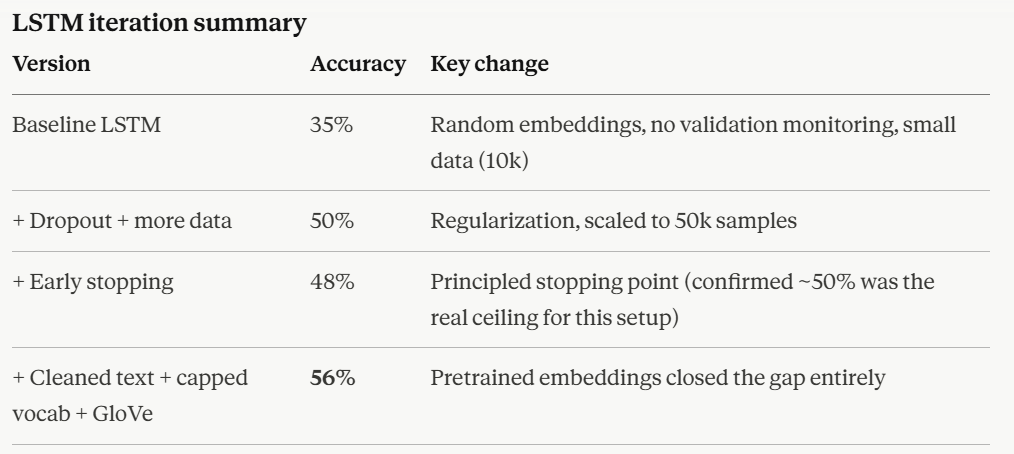

#**Learning:**
Architectural sophistication alone (LSTM vs BoW) wasn't enough to beat a simple baseline — what mattered was giving the model enough signal to learn from. Pretrained GloVe embeddings supplied semantic knowledge that 40,000 training reviews alone couldn't teach from scratch. The LSTM now matches BoW's accuracy while retaining a real architectural advantage BoW lacks entirely: the ability to understand word order and negation (e.g. distinguishing "good" from "not good").

This sets up the next phase — **fine-tuning BERT**, a model pretrained on far more data than GloVe, to see whether deeper contextual understanding pushes accuracy meaningfully beyond this 56% ceiling.